# Stage 3: MPS-Native Cylinder Flow

Channel flow past a cylinder — open-boundary test case for MPS-native LBM.

Boundary conditions (Gross et al.):
- **Walls** (Eq 37): no-slip `b = f_ibar`
- **Inlet** (Eq 38): velocity `b = f_ibar + correction`
- **Outlet** (Eq 39): pressure `b = -f_i + f_eq(rho_0, u_b)`
- **Cylinder** (Eq 40): immersed object bounce-back

### Sections
1. Simulation (vanilla FWBB + MPS, store all data)
2. Velocity Fields
3. Drag & Lift
4. Mass Conservation
5. Bond Dimension & Convergence
6. MPS-Native Observables

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from lbm import (D2Q9, compute_equilibrium, apply_fwbb_cylinder,
                 create_cylinder_mask, create_channel_walls)
from lbm.collision import compute_moments
from tn.compression import compress_populations, decompress_populations
from tn_lbm.collision import collide_bgk_mps
from tn_lbm.boundary import precompute_cylinder_bc, apply_mps_cylinder_bc, mask_to_mps
from tn_lbm.observables import (
    mps_evaluate_at_point, mps_coarse_field,
    compute_drag_lift_mps, check_convergence_mps
)
from tn_lbm.arithmetic import mps_sum_value

print("All modules loaded successfully")

All modules loaded successfully


## 1. Simulation

Run vanilla FWBB and MPS-native side by side. Store everything: drag, lift, mass, velocity convergence, bond dimension.

Cylinder Flow (128x128, Re=100)
  cylinder: center=(32,65), r=16, D=32
  blockage: D/L = 25.0%
  downstream: 80 cells (2D)
  nu=0.032000, tau=0.5960, u_inlet=0.1
  Ma=0.1732
  max_bond=64, mapping=snake
  vanilla: 30000 steps, MPS: 30000 steps
Fluid nodes: 15331, Initial mass: 15331


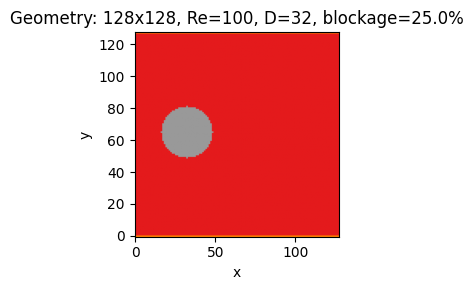

In [30]:
# Parameters — u_inlet=0.1 (matching Gross Ma), D=32, Re=100
n = 128; Re_target = 100; u_inlet = 0.1
cylinder_x, cylinder_y, cylinder_r = n // 4, n // 2 + 1, n // 8  # +1 offset for shedding
D_cyl = 2 * cylinder_r
nu = u_inlet * D_cyl / Re_target
tau = 3 * nu + 0.5
Re = u_inlet * D_cyl / nu
mapping = 'snake'
max_bond_cyl = 64

nt_van = 30000   # vanilla is fast (~2 min), let shedding develop
nt_mps = 30000
snapshot_every_van = max(1, nt_van // 200)  # more snapshots to see oscillation
snapshot_every_mps = max(1, nt_mps // 200)

print(f"Cylinder Flow ({n}x{n}, Re={Re:.0f})")
print(f"  cylinder: center=({cylinder_x},{cylinder_y}), r={cylinder_r}, D={D_cyl}")
print(f"  blockage: D/L = {D_cyl/n*100:.1f}%")
print(f"  downstream: {n - cylinder_x - cylinder_r} cells ({(n - cylinder_x - cylinder_r)/D_cyl:.0f}D)")
print(f"  nu={nu:.6f}, tau={tau:.4f}, u_inlet={u_inlet}")
print(f"  Ma={u_inlet / np.sqrt(D2Q9.cs2):.4f}")
print(f"  max_bond={max_bond_cyl}, mapping={mapping}")
print(f"  vanilla: {nt_van} steps, MPS: {nt_mps} steps")
print("=" * 60)

# Geometry
cylinder = create_cylinder_mask(n, n, cylinder_x, cylinder_y, cylinder_r)
walls = create_channel_walls(n, n)
solid = cylinder | walls
fluid = ~solid

# Per-direction boundary masks for momentum exchange drag/lift
cyl_boundary_masks_2d = [None] * D2Q9.q
cyl_boundary_masks_mps = [None] * D2Q9.q
for i in range(D2Q9.q):
    cx_i, cy_i = int(D2Q9.c[i, 0]), int(D2Q9.c[i, 1])
    if cx_i == 0 and cy_i == 0:
        continue
    shifted = np.roll(np.roll(cylinder, cx_i, axis=0), cy_i, axis=1)
    mask_2d = shifted & fluid
    cyl_boundary_masks_2d[i] = mask_2d
    cyl_boundary_masks_mps[i], _ = mask_to_mps(mask_2d, mapping=mapping)

# Initial condition
rho_init = np.ones((n, n))
u_init = np.zeros((2, n, n))
u_init[0, fluid] = u_inlet
f_init = compute_equilibrium(D2Q9, rho_init, u_init)
for i in range(D2Q9.q):
    f_init[i][solid] = 0.0

initial_mass = np.sum(f_init)
print(f"Fluid nodes: {fluid.sum()}, Initial mass: {initial_mass:.0f}")

# Visualize geometry
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
geo = np.zeros((n, n)); geo[walls] = 1; geo[cylinder] = 2
ax.imshow(geo.T, origin='lower', cmap='Set1', aspect='equal')
ax.set_title(f'Geometry: {n}x{n}, Re={Re:.0f}, D={D_cyl}, blockage={D_cyl/n*100:.1f}%')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout(); plt.show()

In [11]:
def dense_drag_lift(lattice, f, cylinder_mask, fluid_mask):
    """Momentum exchange drag/lift on cylinder."""
    drag, lift = 0.0, 0.0
    for i in range(lattice.q):
        cx_i, cy_i = int(lattice.c[i, 0]), int(lattice.c[i, 1])
        opp = lattice.opposite[i]
        if cx_i == 0 and cy_i == 0:
            continue
        shifted = np.roll(np.roll(cylinder_mask, cx_i, axis=0), cy_i, axis=1)
        boundary = shifted & fluid_mask
        fsum = f[i] + f[opp]
        drag += cx_i * (fsum * boundary).sum()
        lift += cy_i * (fsum * boundary).sum()
    return drag, lift

def safe_moments(lattice, f):
    """Same as compute_moments but with safe division (no NaN at solid rho=0 nodes)."""
    rho = np.sum(f, axis=0)
    rho_safe = np.where(rho > 1e-15, rho, 1.0)
    u = np.zeros((2, *rho.shape))
    for i in range(lattice.q):
        u[0] += lattice.c[i, 0] * f[i]
        u[1] += lattice.c[i, 1] * f[i]
    u /= rho_safe
    return rho, u

# --- Storage ---
van = {'t': [], 'mass': [], 'drag': [], 'lift': [], 'du': []}
mps = {'t': [], 'mass': [], 'drag': [], 'lift': [], 'du': [], 'mean_chi': []}

# ========== Vanilla FWBB ==========
print("Running vanilla FWBB...")
f_van = f_init.copy()
u_prev_van = u_init.copy()
t0 = time.time()

for t in range(nt_van + 1):
    rho_v, u_v = safe_moments(D2Q9, f_van)

    if t % snapshot_every_van == 0:
        du_v = np.sqrt(np.sum((u_v[:, fluid] - u_prev_van[:, fluid])**2) /
                       (np.sum(u_v[:, fluid]**2) + 1e-30))
        drag_v, lift_v = dense_drag_lift(D2Q9, f_van, cylinder, fluid)
        mass_v = rho_v.sum()

        van['t'].append(t)
        van['mass'].append(mass_v)
        van['drag'].append(drag_v)
        van['lift'].append(lift_v)
        van['du'].append(du_v)

    u_prev_van = u_v.copy()

    if t < nt_van:
        f_eq = compute_equilibrium(D2Q9, rho_v, u_v)
        f_star = f_van - (1.0 / tau) * (f_van - f_eq)
        f_van = apply_fwbb_cylinder(D2Q9, f_star, cylinder, walls, u_inlet, rho_inlet=1.0)

van_time = time.time() - t0
lifts_arr = np.array(van['lift'])
last_lifts = lifts_arr[-20:]
print(f"  Done in {van_time:.1f}s ({van_time/(nt_van+1)*1000:.0f}ms/step)")
print(f"  Final du={van['du'][-1]:.2e}, drag={van['drag'][-1]:.4f}")
print(f"  Lift: final={van['lift'][-1]:.4f}, last-20 range=[{last_lifts.min():.4f}, {last_lifts.max():.4f}], amp={( last_lifts.max()-last_lifts.min())/2:.4f}")
print(f"  Shedding: {'YES' if (last_lifts.max()-last_lifts.min())/2 > 0.005 else 'NO (amp < 0.005)'}")

Running vanilla FWBB...
  Done in 107.8s (4ms/step)
  Final du=9.23e-04, drag=-0.8421
  Lift: final=0.0459, last-20 range=[-0.1968, 0.1961], amp=0.1965
  Shedding: YES


In [ ]:
# ========== MPS-Native ==========
print(f"Precomputing MPS boundary data...")
bc_data = precompute_cylinder_bc(n, D2Q9, u_inlet, rho_inlet=1.0,
                                  cylinder_x=cylinder_x, cylinder_y=cylinder_y,
                                  cylinder_r=cylinder_r, mapping=mapping)
meta = bc_data['metadata']

mps_chi = 128
mps_cutoff = 0
mps_log_every = 100  # print progress every 100 steps

print(f"Running MPS-native (max_bond={mps_chi}, cutoff={mps_cutoff}, {nt_mps} steps)...")
mps_list, _ = compress_populations(f_init, mapping=mapping)
moments_prev = None
du_val = 1.0
t0 = time.time()

for t in range(nt_mps + 1):
    if t % snapshot_every_mps == 0:
        mass_m = sum(mps_sum_value(mps_list[i]) for i in range(D2Q9.q))
        drag_m, lift_m = compute_drag_lift_mps(mps_list, D2Q9, cyl_boundary_masks_mps,
                                                max_bond=mps_chi)
        mean_chi = np.mean([m.max_bond() for m in mps_list])

        mps['t'].append(t)
        mps['mass'].append(mass_m)
        mps['drag'].append(drag_m)
        mps['lift'].append(lift_m)
        mps['du'].append(du_val)
        mps['mean_chi'].append(mean_chi)

    if t < nt_mps:
        mps_list, moments_new = collide_bgk_mps(mps_list, D2Q9, tau, n,
                                                  max_bond=mps_chi, cutoff=mps_cutoff,
                                                  return_moments=True)
        if moments_prev is not None:
            _, du_val = check_convergence_mps(mps_list, mps_list, mode='velocity',
                                               moments_new=moments_new, moments_old=moments_prev)
        moments_prev = moments_new

        mps_list = apply_mps_cylinder_bc(mps_list, D2Q9, bc_data,
                                          max_bond=mps_chi, cutoff=mps_cutoff)

    if t > 0 and t % mps_log_every == 0:
        elapsed = time.time() - t0
        print(f"  t={t}, du={du_val:.2e}, drag={mps['drag'][-1] if mps['drag'] else 0:.4f}, "
              f"lift={mps['lift'][-1] if mps['lift'] else 0:.4f}, "
              f"chi={mean_chi:.0f}, {elapsed/t:.1f}s/step, ETA={((nt_mps-t)*elapsed/t)/3600:.1f}h")

mps_time = time.time() - t0
mps_lifts = np.array(mps['lift'])
last_mps_lifts = mps_lifts[-20:]
print(f"  Done in {mps_time:.0f}s ({mps_time/(nt_mps+1)*1000:.0f}ms/step)")
print(f"  Final du={mps['du'][-1]:.2e}, drag={mps['drag'][-1]:.4f}")
print(f"  Lift: last-20 range=[{last_mps_lifts.min():.4f}, {last_mps_lifts.max():.4f}], amp={(last_mps_lifts.max()-last_mps_lifts.min())/2:.4f}")

Precomputing MPS boundary data...
Running MPS-native (max_bond=128, cutoff=0, 30000 steps)...


## 2. Velocity Fields

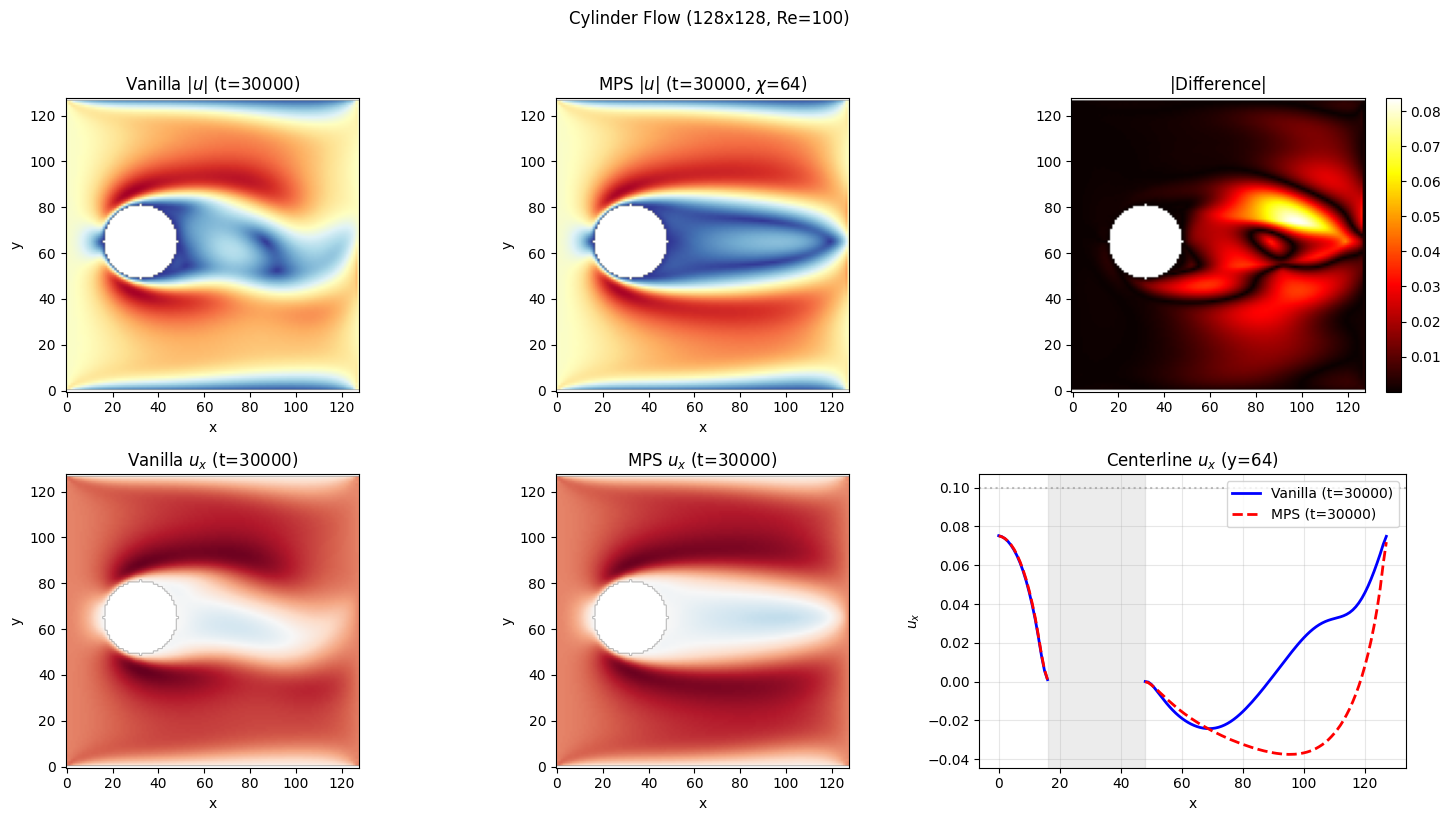

In [22]:
# Final state
_, u_van_final = compute_moments(D2Q9, f_van)
rho_van_final = np.sum(f_van, axis=0)
rho_safe_v = np.where(rho_van_final > 1e-15, rho_van_final, 1.0)
u_van_final = np.stack([
    np.sum(f_van * D2Q9.c[:, 0, None, None], axis=0) / rho_safe_v,
    np.sum(f_van * D2Q9.c[:, 1, None, None], axis=0) / rho_safe_v
])

f_mps_final = decompress_populations(mps_list, meta)
rho_mps_final = np.sum(f_mps_final, axis=0)
rho_safe_m = np.where(rho_mps_final > 1e-15, rho_mps_final, 1.0)
u_mps_final = np.stack([
    np.sum(f_mps_final * D2Q9.c[:, 0, None, None], axis=0) / rho_safe_m,
    np.sum(f_mps_final * D2Q9.c[:, 1, None, None], axis=0) / rho_safe_m
])

speed_van = np.sqrt(u_van_final[0]**2 + u_van_final[1]**2)
speed_mps = np.sqrt(u_mps_final[0]**2 + u_mps_final[1]**2)

# Mask solid for visualization
speed_van_vis = np.where(fluid, speed_van, np.nan)
speed_mps_vis = np.where(fluid, speed_mps, np.nan)
vmax = max(np.nanmax(speed_van_vis), np.nanmax(speed_mps_vis))

# L2 error (only over steps both ran — compare at MPS final time)
du_L2 = np.sqrt(((u_mps_final[0] - u_van_final[0])**2 +
                  (u_mps_final[1] - u_van_final[1])**2)[fluid].sum() /
                ((u_van_final[0]**2 + u_van_final[1]**2)[fluid].sum() + 1e-30))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Row 1: speed
axes[0, 0].imshow(speed_van_vis.T, origin='lower', cmap='RdYlBu_r', vmin=0, vmax=vmax)
axes[0, 0].set_title(f'Vanilla $|u|$ (t={nt_van})')
axes[0, 1].imshow(speed_mps_vis.T, origin='lower', cmap='RdYlBu_r', vmin=0, vmax=vmax)
axes[0, 1].set_title(f'MPS $|u|$ (t={nt_mps}, $\\chi$={max_bond_cyl})')

diff_speed = np.where(fluid, np.abs(speed_mps - speed_van), np.nan)
im2 = axes[0, 2].imshow(diff_speed.T, origin='lower', cmap='hot')
axes[0, 2].set_title(f'$|$Difference$|$')
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046)

# Row 2: ux + centerline
ux_van_vis = np.where(fluid, u_van_final[0], np.nan)
ux_mps_vis = np.where(fluid, u_mps_final[0], np.nan)
vabs = max(abs(np.nanmin(ux_van_vis)), np.nanmax(ux_van_vis))

axes[1, 0].imshow(ux_van_vis.T, origin='lower', cmap='RdBu_r', vmin=-vabs, vmax=vabs)
axes[1, 0].set_title(f'Vanilla $u_x$ (t={nt_van})')
axes[1, 1].imshow(ux_mps_vis.T, origin='lower', cmap='RdBu_r', vmin=-vabs, vmax=vabs)
axes[1, 1].set_title(f'MPS $u_x$ (t={nt_mps})')

# Centerline profiles
yc = n // 2
xs = np.arange(n)
in_cyl = np.sqrt((xs - cylinder_x)**2 + (yc - cylinder_y)**2) <= cylinder_r
ux_c_van = u_van_final[0, :, yc].copy(); ux_c_van[in_cyl | walls[:, yc]] = np.nan
ux_c_mps = u_mps_final[0, :, yc].copy(); ux_c_mps[in_cyl | walls[:, yc]] = np.nan

axes[1, 2].plot(xs, ux_c_van, 'b-', linewidth=2, label=f'Vanilla (t={nt_van})')
axes[1, 2].plot(xs, ux_c_mps, 'r--', linewidth=2, label=f'MPS (t={nt_mps})')
axes[1, 2].axhline(u_inlet, color='gray', ls=':', alpha=0.5)
axes[1, 2].axvspan(cylinder_x - cylinder_r, cylinder_x + cylinder_r, alpha=0.15, color='gray')
axes[1, 2].set_xlabel('x'); axes[1, 2].set_ylabel('$u_x$')
axes[1, 2].set_title(f'Centerline $u_x$ (y={yc})')
axes[1, 2].legend(); axes[1, 2].grid(True, alpha=0.3)

for ax in axes[:, :2].flat:
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle(f'Cylinder Flow ({n}x{n}, Re={Re:.0f})', y=1.02)
plt.tight_layout(); plt.show()


## 3. Drag & Lift

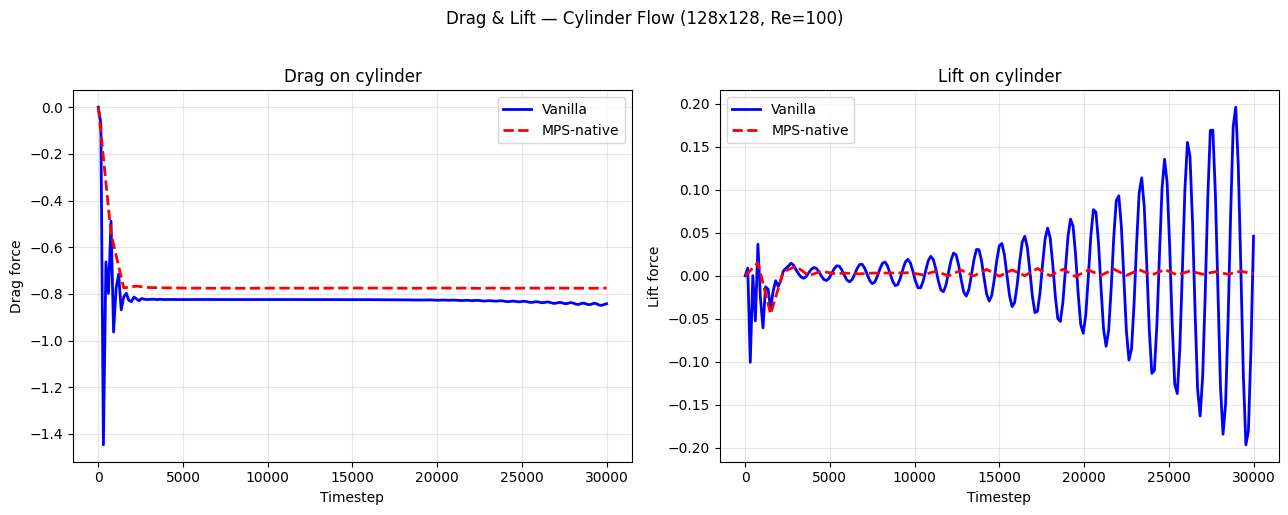

Final drag: vanilla=-0.842063, MPS=-0.774747, diff=6.73e-02
Final lift: vanilla=0.045934, MPS=0.002262, diff=4.37e-02


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(van['t'], van['drag'], 'b-', linewidth=2, label='Vanilla')
ax.plot(mps['t'], mps['drag'], 'r--', linewidth=2, label='MPS-native')
ax.set_xlabel('Timestep'); ax.set_ylabel('Drag force')
ax.set_title('Drag on cylinder'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(van['t'], van['lift'], 'b-', linewidth=2, label='Vanilla')
ax.plot(mps['t'], mps['lift'], 'r--', linewidth=2, label='MPS-native')
ax.set_xlabel('Timestep'); ax.set_ylabel('Lift force')
ax.set_title('Lift on cylinder'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Drag & Lift — Cylinder Flow ({n}x{n}, Re={Re:.0f})', y=1.02)
plt.tight_layout(); plt.show()

print(f"Final drag: vanilla={van['drag'][-1]:.6f}, MPS={mps['drag'][-1]:.6f}, "
      f"diff={abs(mps['drag'][-1]-van['drag'][-1]):.2e}")
print(f"Final lift: vanilla={van['lift'][-1]:.6f}, MPS={mps['lift'][-1]:.6f}, "
      f"diff={abs(mps['lift'][-1]-van['lift'][-1]):.2e}")

## 4. Mass Conservation

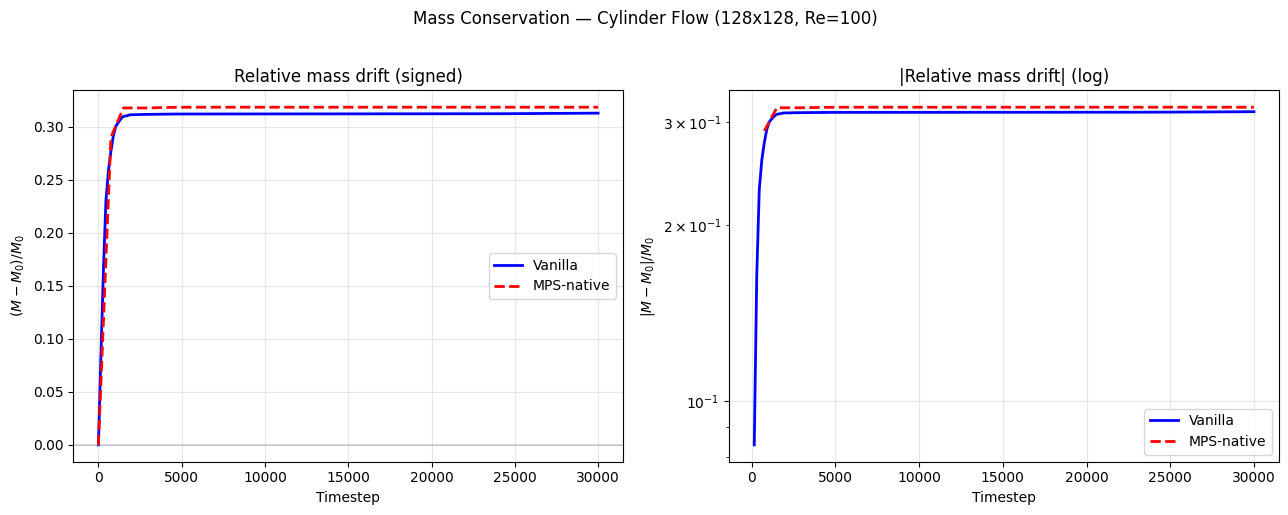

Final mass drift:
  Vanilla:    3.13e-01 (+31.29%)
  MPS-native: 3.19e-01 (+31.85%)

Note: open boundaries (Eq 38/39) do NOT conserve mass — the density
adjusts to establish the pressure gradient needed for the flow.


In [24]:
van_mass_rel = [(m - initial_mass) / initial_mass for m in van['mass']]
mps_mass_rel = [(m - initial_mass) / initial_mass for m in mps['mass']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(van['t'], van_mass_rel, 'b-', linewidth=2, label='Vanilla')
ax.plot(mps['t'], mps_mass_rel, 'r--', linewidth=2, label='MPS-native')
ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Timestep'); ax.set_ylabel('$(M - M_0) / M_0$')
ax.set_title('Relative mass drift (signed)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
rd_v = [max(abs(r), 1e-16) for r in van_mass_rel[1:]]
rd_m = [max(abs(r), 1e-16) for r in mps_mass_rel[1:]]
ax.semilogy(van['t'][1:], rd_v, 'b-', linewidth=2, label='Vanilla')
ax.semilogy(mps['t'][1:], rd_m, 'r--', linewidth=2, label='MPS-native')
ax.set_xlabel('Timestep'); ax.set_ylabel('$|M - M_0| / M_0$')
ax.set_title('|Relative mass drift| (log)'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Mass Conservation — Cylinder Flow ({n}x{n}, Re={Re:.0f})', y=1.02)
plt.tight_layout(); plt.show()

print(f"Final mass drift:")
print(f"  Vanilla:    {van_mass_rel[-1]:.2e} ({van_mass_rel[-1]*100:+.2f}%)")
print(f"  MPS-native: {mps_mass_rel[-1]:.2e} ({mps_mass_rel[-1]*100:+.2f}%)")
print(f"\nNote: open boundaries (Eq 38/39) do NOT conserve mass — the density")
print(f"adjusts to establish the pressure gradient needed for the flow.")

## 5. Bond Dimension & Convergence

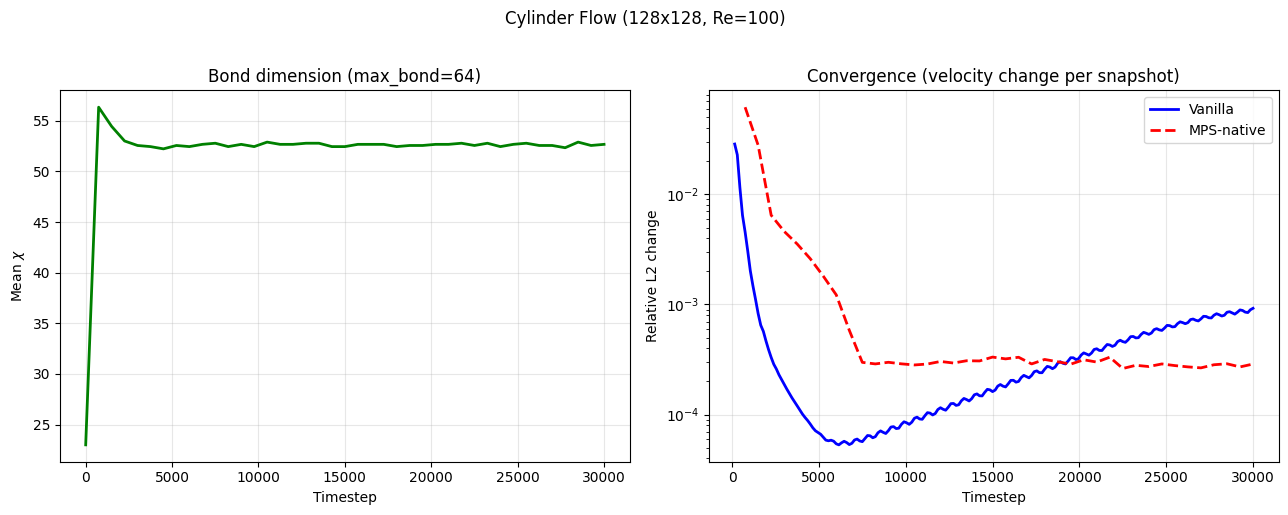

Bond dimension: min=23.0, max=56.3
Final du: vanilla=9.23e-04, MPS=2.88e-04


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(mps['t'], mps['mean_chi'], 'g-', linewidth=2)
ax.set_xlabel('Timestep'); ax.set_ylabel('Mean $\\chi$')
ax.set_title(f'Bond dimension (max_bond={max_bond_cyl})'); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(van['t'][1:], van['du'][1:], 'b-', linewidth=2, label='Vanilla')
mps_du_valid = [(t, d) for t, d in zip(mps['t'], mps['du']) if d < 1.0]
if mps_du_valid:
    ax.semilogy([x[0] for x in mps_du_valid], [x[1] for x in mps_du_valid],
                'r--', linewidth=2, label='MPS-native')
ax.set_xlabel('Timestep'); ax.set_ylabel('Relative L2 change')
ax.set_title('Convergence (velocity change per snapshot)'); ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Cylinder Flow ({n}x{n}, Re={Re:.0f})', y=1.02)
plt.tight_layout(); plt.show()

print(f"Bond dimension: min={min(mps['mean_chi']):.1f}, max={max(mps['mean_chi']):.1f}")
print(f"Final du: vanilla={van['du'][-1]:.2e}, MPS={mps['du'][-1]:.2e}")

## 6. MPS-Native Observables

Extract data from the final MPS state without decompression.

In [26]:
# Point evaluation: wake centerline ux
print("Wake centerline ux point evaluation:")
print(f"{'x':>4} | {'Vanilla':>12} | {'MPS decomp':>12} | {'MPS point':>12} | {'pt vs dec':>10} | {'pt vs van':>10}")
print("-" * 80)

probe_y = n // 2
probe_xs = np.arange(cylinder_x + cylinder_r + 2, n - 1, 4)
max_pt_err_dec = 0
max_pt_err_van = 0

for px in probe_xs:
    rho_pt = sum(mps_evaluate_at_point(mps_list[i], px, probe_y, n, meta)
                  for i in range(D2Q9.q))
    rhou_x_pt = sum(D2Q9.c[i, 0] * mps_evaluate_at_point(mps_list[i], px, probe_y, n, meta)
                     for i in range(D2Q9.q))
    ux_pt = rhou_x_pt / rho_pt if abs(rho_pt) > 1e-15 else 0.0

    ux_van_val = u_van_final[0, px, probe_y]
    ux_dec_val = u_mps_final[0, px, probe_y]

    err_dec = abs(ux_pt - ux_dec_val)
    err_van = abs(ux_pt - ux_van_val)
    max_pt_err_dec = max(max_pt_err_dec, err_dec)
    max_pt_err_van = max(max_pt_err_van, err_van)

    print(f"{px:4d} | {ux_van_val:>12.6e} | {ux_dec_val:>12.6e} | {ux_pt:>12.6e} | {err_dec:>10.2e} | {err_van:>10.2e}")

print(f"\nMax errors:")
print(f"  MPS point vs MPS decompressed: {max_pt_err_dec:.2e}  (compression roundtrip)")
print(f"  MPS point vs vanilla:          {max_pt_err_van:.2e}  (compression + Taylor 1/rho)")

# Drag/lift from MPS (per-direction masks)
drag_m_final, lift_m_final = compute_drag_lift_mps(mps_list, D2Q9, cyl_boundary_masks_mps,
                                                     max_bond=max_bond_cyl)
drag_v_final, lift_v_final = dense_drag_lift(D2Q9, f_van, cylinder, fluid)
print(f"\nDrag: vanilla={drag_v_final:.6f}, MPS={drag_m_final:.6f}, diff={abs(drag_m_final-drag_v_final):.2e}")
print(f"Lift: vanilla={lift_v_final:.6f}, MPS={lift_m_final:.6f}, diff={abs(lift_m_final-lift_v_final):.2e}")

# Mass from MPS
mass_mps_final = sum(mps_sum_value(mps_list[i]) for i in range(D2Q9.q))
mass_van_final = np.sum(f_van)
print(f"\nMass: vanilla={mass_van_final:.4f}, MPS={mass_mps_final:.4f}")

Wake centerline ux point evaluation:
   x |      Vanilla |   MPS decomp |    MPS point |  pt vs dec |  pt vs van
--------------------------------------------------------------------------------
  50 | -1.392568e-03 | -1.682427e-03 | -1.682427e-03 |   1.77e-16 |   2.90e-04
  54 | -9.220736e-03 | -7.335217e-03 | -7.335217e-03 |   1.99e-16 |   1.89e-03
  58 | -1.623506e-02 | -1.298776e-02 | -1.298776e-02 |   3.99e-17 |   3.25e-03
  62 | -2.101066e-02 | -1.784507e-02 | -1.784507e-02 |   6.94e-18 |   3.17e-03
  66 | -2.364833e-02 | -2.193971e-02 | -2.193971e-02 |   1.39e-17 |   1.71e-03
  70 | -2.415265e-02 | -2.544699e-02 | -2.544699e-02 |   6.94e-17 |   1.29e-03
  74 | -2.235963e-02 | -2.851646e-02 | -2.851646e-02 |   2.60e-16 |   6.16e-03
  78 | -1.824197e-02 | -3.116516e-02 | -3.116516e-02 |   1.49e-16 |   1.29e-02
  82 | -1.219957e-02 | -3.344770e-02 | -3.344770e-02 |   2.08e-16 |   2.12e-02
  86 | -4.908195e-03 | -3.533368e-02 | -3.533368e-02 |   2.57e-16 |   3.04e-02
  90 | 3.061542e

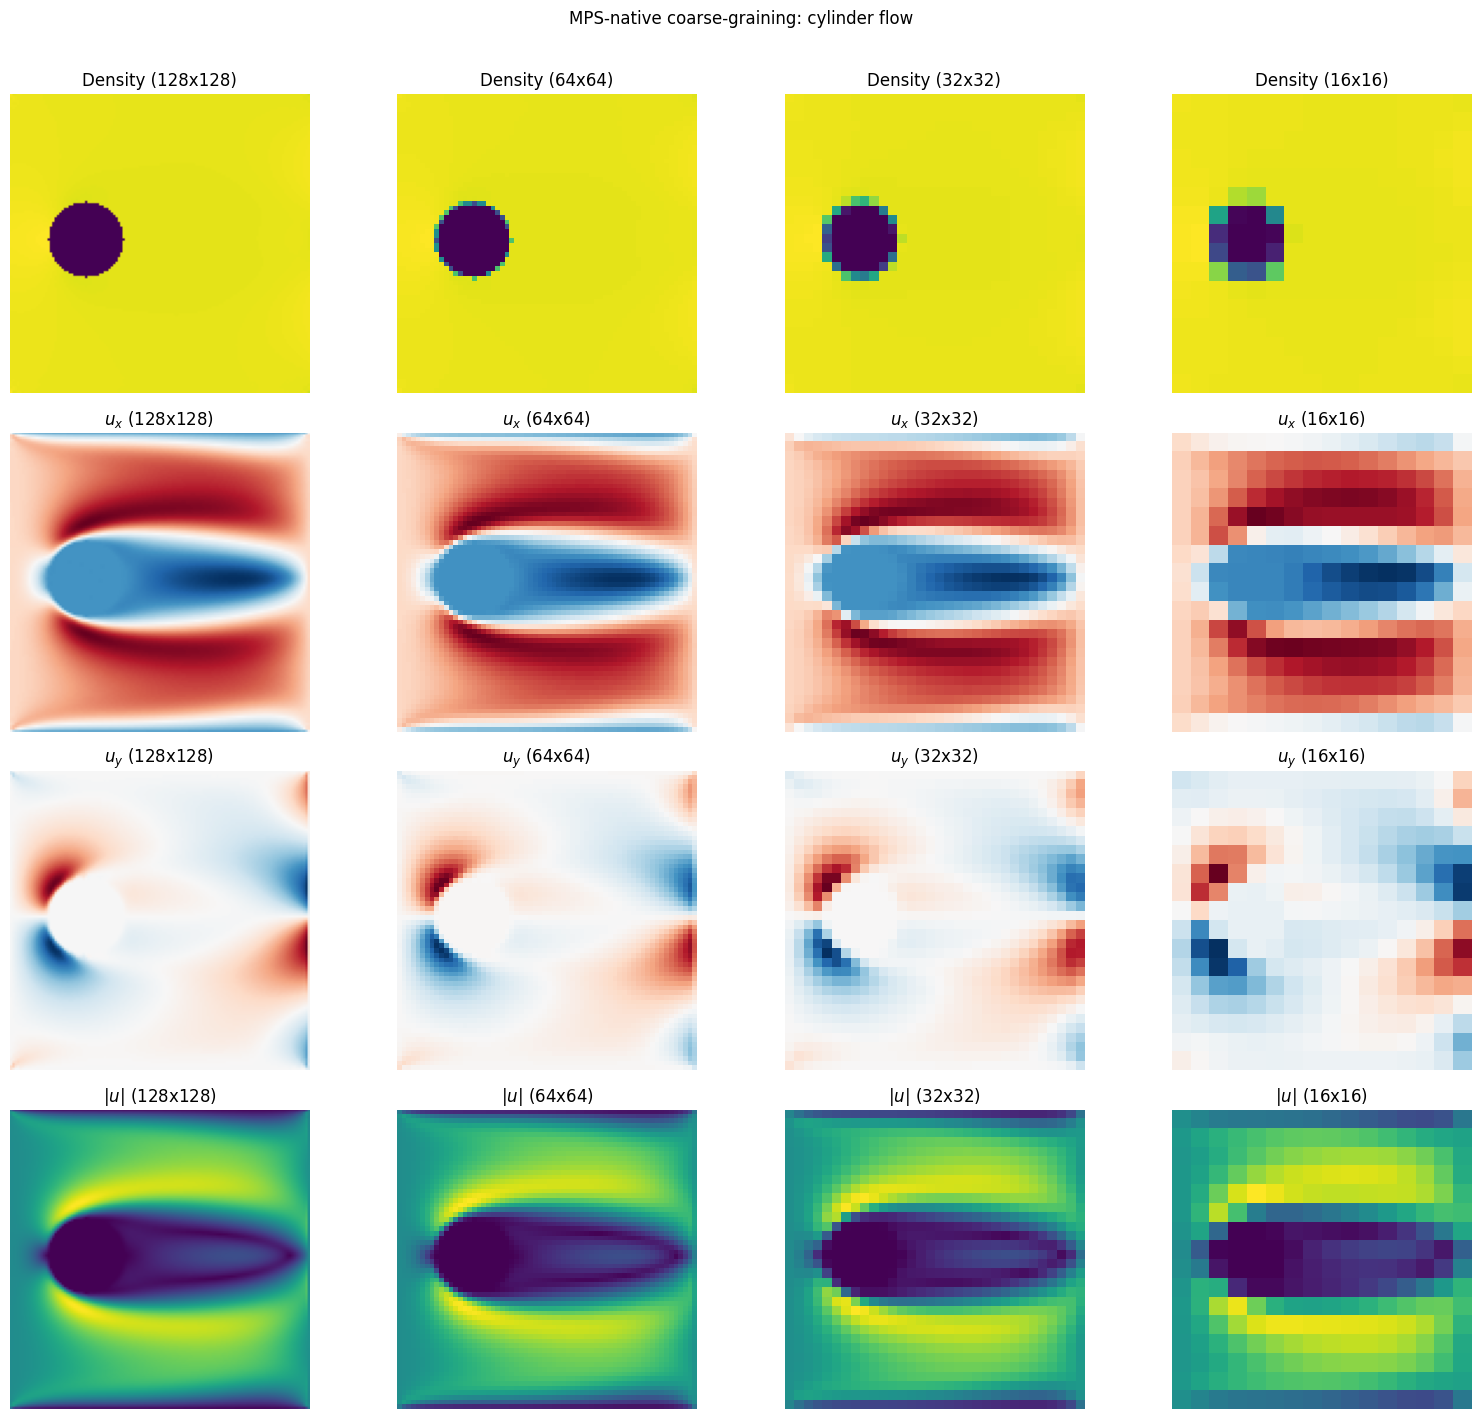

Coarse field validation (max error vs dense reshape+sum):
  rho level=1 (64x64): err=9.77e-15
  rho level=2 (32x32): err=4.97e-14
  rho level=3 (16x16): err=1.56e-13
  ux level=1 (64x64): err=9.44e-16
  ux level=2 (32x32): err=4.00e-15
  ux level=3 (16x16): err=1.51e-14
  uy level=1 (64x64): err=5.00e-16
  uy level=2 (32x32): err=1.22e-15
  uy level=3 (16x16): err=4.88e-15


In [27]:
# Coarse-graining
from tn_lbm.collision import compute_moments_mps, compute_inverse_density_mps, build_ones_mps
from tn_lbm.arithmetic import mps_hadamard
from tn.compression import qtt_to_field

rho_mps_cg, rhou_x_mps_cg, rhou_y_mps_cg = compute_moments_mps(mps_list, D2Q9, max_bond=max_bond_cyl)
ones_cg = build_ones_mps(len(mps_list[0].tensors))
inv_rho_cg = compute_inverse_density_mps(rho_mps_cg, ones_cg, n, max_bond=max_bond_cyl)
ux_mps_cg = mps_hadamard(rhou_x_mps_cg, inv_rho_cg, max_bond=max_bond_cyl)
uy_mps_cg = mps_hadamard(rhou_y_mps_cg, inv_rho_cg, max_bond=max_bond_cyl)

fig, axes = plt.subplots(4, 4, figsize=(16, 14))

fields = [
    (rho_mps_cg, 'Density', 'viridis'),
    (ux_mps_cg, '$u_x$', 'RdBu_r'),
    (uy_mps_cg, '$u_y$', 'RdBu_r'),
]

for row, (field_mps, field_name, cmap) in enumerate(fields):
    full = qtt_to_field(field_mps, meta)
    axes[row, 0].imshow(full.T, origin='lower', cmap=cmap)
    axes[row, 0].set_title(f'{field_name} ({n}x{n})'); axes[row, 0].axis('off')
    for col, level in enumerate([1, 2, 3]):
        coarse = mps_coarse_field(field_mps, meta, coarse_level=level)
        n_c = n // (2**level)
        axes[row, col+1].imshow(coarse.T, origin='lower', cmap=cmap)
        axes[row, col+1].set_title(f'{field_name} ({n_c}x{n_c})'); axes[row, col+1].axis('off')

# Row 4: speed
ux_full = qtt_to_field(ux_mps_cg, meta)
uy_full = qtt_to_field(uy_mps_cg, meta)
speed_full = np.sqrt(ux_full**2 + uy_full**2)
axes[3, 0].imshow(speed_full.T, origin='lower', cmap='viridis')
axes[3, 0].set_title(f'$|u|$ ({n}x{n})'); axes[3, 0].axis('off')

for col, level in enumerate([1, 2, 3]):
    ux_c = mps_coarse_field(ux_mps_cg, meta, coarse_level=level)
    uy_c = mps_coarse_field(uy_mps_cg, meta, coarse_level=level)
    n_c = n // (2**level)
    block = 2**level
    speed_c = np.sqrt((ux_c / block**2)**2 + (uy_c / block**2)**2)
    axes[3, col+1].imshow(speed_c.T, origin='lower', cmap='viridis')
    axes[3, col+1].set_title(f'$|u|$ ({n_c}x{n_c})'); axes[3, col+1].axis('off')

plt.suptitle('MPS-native coarse-graining: cylinder flow', y=1.01)
plt.tight_layout(); plt.show()

# Validation
print("Coarse field validation (max error vs dense reshape+sum):")
for field_mps, name in [(rho_mps_cg, 'rho'), (ux_mps_cg, 'ux'), (uy_mps_cg, 'uy')]:
    full = qtt_to_field(field_mps, meta)
    for level in [1, 2, 3]:
        coarse = mps_coarse_field(field_mps, meta, coarse_level=level)
        n_c = n // (2**level)
        block = 2**level
        dense_coarse = full.reshape(n_c, block, n_c, block).sum(axis=(1, 3))
        err = np.max(np.abs(coarse - dense_coarse))
        print(f"  {name} level={level} ({n_c}x{n_c}): err={err:.2e}")